# Bloque 3 — Procesamiento masivo y computación distribuida

**Módulo:** Extracción, Transformación y Carga de Datos desde Fuentes Múltiples (5104)
**Unidad Didáctica:** UD1 — Tipología y características de las fuentes de datos
**Duración estimada:** ~6 horas
**Curso académico:** 2026-2027

---

### Contenidos de este bloque

| Epígrafe | Contenido |
|----------|-----------|
| **3.1** | Paradigmas de procesamiento: batch, micro-batch y streaming |
| **3.2** | Procesamiento en chunks con pandas |
| **3.3** | Dask: paralelismo transparente en local |
| **3.4** | Apache Spark: arquitectura y modelo MapReduce |
| **3.5** | Particionado, shuffling y optimización |
| **3.6** | Aprendizaje online y streaming con scikit-learn |

### Criterios de evaluación asociados
> **(CE g)** Se han identificado las principales herramientas y plataformas para el procesamiento
> masivo de datos orientado al aprendizaje automático.
> **(CE h)** Se han aplicado técnicas de procesamiento distribuido y en tiempo real a conjuntos
> de datos de gran volumen.

---


In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import time
import subprocess
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("Librerias cargadas correctamente.")


Librerias cargadas correctamente.


---
## 3.1 Paradigmas de procesamiento masivo

Cuando el volumen de datos supera la RAM de una sola máquina —o cuando los datos llegan
de forma continua— necesitamos estrategias de **procesamiento masivo**.
Los tres paradigmas principales son:

| Paradigma | Latencia típica | Caso de uso en ML | Herramientas |
|-----------|----------------|-------------------|--------------|
| **Batch** | Minutos / horas | ETL nocturno, reentrenamiento periódico | Spark, Hadoop |
| **Micro-batch** | Segundos / minutos | Dashboards casi-tiempo-real | Spark Structured Streaming |
| **Streaming** | Milisegundos | Detección de fraude en tiempo real | Flink, Kafka Streams |

**Regla práctica para ML:** ¿cuándo necesitas el resultado?

- **Ya** → streaming (latencia < 1 s)
- **En minutos** → micro-batch
- **Puedo esperar horas** → batch (más sencillo y más barato)

El diagrama siguiente muestra cómo varía el flujo de datos en cada paradigma.


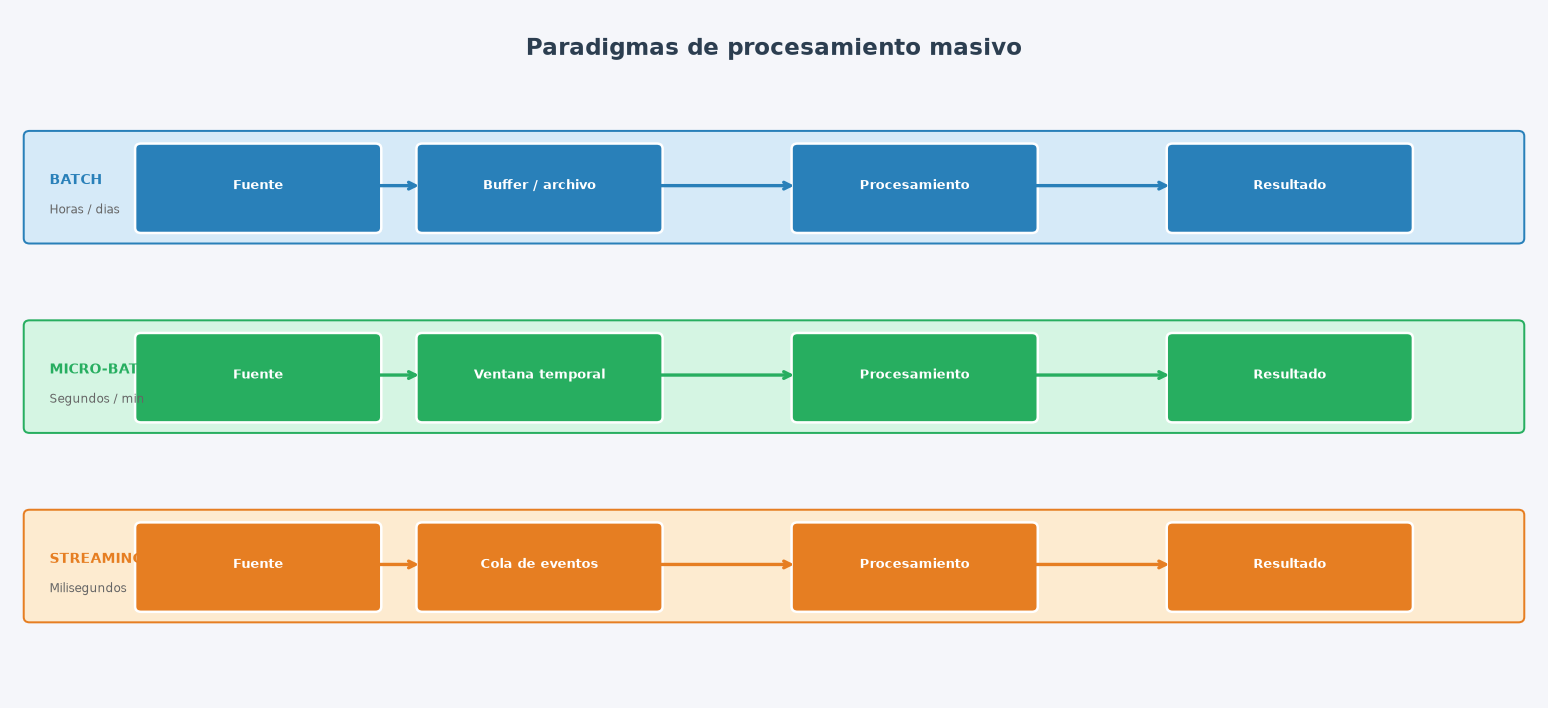

Diagrama 1: Paradigmas de procesamiento masivo


In [2]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.set_xlim(0, 13)
ax.set_ylim(0, 6.5)
ax.set_axis_off()
ax.set_facecolor('#f5f6fa')
fig.patch.set_facecolor('#f5f6fa')

ax.text(6.5, 6.15, 'Paradigmas de procesamiento masivo', ha='center', va='center',
        fontsize=14, fontweight='bold', color='#2c3e50')

paradigmas = [
    ('BATCH',       'Horas / dias',    '#2980b9', '#d6eaf8', 4.8),
    ('MICRO-BATCH', 'Segundos / min',  '#27ae60', '#d5f5e3', 3.0),
    ('STREAMING',   'Milisegundos',    '#e67e22', '#fdebd0', 1.2),
]

etiquetas_etapas = [
    ['Fuente',  'Buffer / archivo', 'Procesamiento', 'Resultado'],
    ['Fuente',  'Ventana temporal', 'Procesamiento', 'Resultado'],
    ['Fuente',  'Cola de eventos',  'Procesamiento', 'Resultado'],
]

x_boxes = [1.1, 3.5, 6.7, 9.9]
w = 2.0
h = 0.75

for (nombre, latencia, color, color_bg, y0), etapas in zip(paradigmas, etiquetas_etapas):
    bg = FancyBboxPatch((0.15, y0 - 0.45), 12.7, h + 0.22,
                        boxstyle="round,pad=0.05",
                        facecolor=color_bg, edgecolor=color, linewidth=1.2)
    ax.add_patch(bg)
    ax.text(0.32, y0 + 0.10, nombre, ha='left', va='center',
            fontsize=8.5, fontweight='bold', color=color)
    ax.text(0.32, y0 - 0.18, latencia, ha='left', va='center',
            fontsize=7, color='#666666')
    for j, (x0, etapa) in enumerate(zip(x_boxes, etapas)):
        box = FancyBboxPatch((x0, y0 - 0.35), w, h,
                             boxstyle="round,pad=0.05",
                             facecolor=color, edgecolor='white', linewidth=1.5)
        ax.add_patch(box)
        ax.text(x0 + w / 2, y0 + 0.05, etapa, ha='center', va='center',
                fontsize=8, fontweight='bold', color='white')
        if j < len(x_boxes) - 1:
            ax.annotate('', xy=(x_boxes[j + 1], y0 + 0.05),
                        xytext=(x0 + w, y0 + 0.05),
                        arrowprops=dict(arrowstyle='->', color=color, lw=2.0))

plt.tight_layout()
plt.savefig('diagrama_b3_paradigmas.png', dpi=120, bbox_inches='tight')
plt.show()
print("Diagrama 1: Paradigmas de procesamiento masivo")


---
## 3.2 Procesamiento en chunks con pandas

La técnica más sencilla para procesar ficheros que no caben en RAM es
**leer el CSV en trozos (chunks)**. `pd.read_csv(..., chunksize=N)` devuelve un
iterador que carga N filas en cada iteración:

```python
for chunk in pd.read_csv('grande.csv', chunksize=50_000):
    # chunk es un DataFrame con 50 000 filas
    procesar(chunk)
```

**Limitaciones:**
- Solo funciona para operaciones **acumulables** (suma, conteo, mín, máx).
- Operaciones globales como la mediana o el ordenado completo no son acumulables
  de forma directa.
- Un solo hilo: no aprovecha múltiples núcleos de CPU.

Vamos a generar un CSV sintético grande y aplicarle una agregación por chunks.


In [5]:
N_FILAS = 600_000
print(f"Generando CSV sintetico con {N_FILAS:,} filas...")

np.random.seed(42)
df_grande = pd.DataFrame({
    'id':          range(N_FILAS),
    'sensor':      np.random.choice(['A', 'B', 'C', 'D'], N_FILAS),
    'valor':       np.random.randn(N_FILAS),
    'temperatura': np.random.uniform(15.0, 85.0, N_FILAS),
    'activo':      np.random.choice([True, False], N_FILAS),
})

RUTA_CSV = Path('datos_grandes.csv')
df_grande.to_csv(RUTA_CSV, index=False)
tam_mb = RUTA_CSV.stat().st_size / 1e6
print(f"CSV guardado: {RUTA_CSV}  ({tam_mb:.1f} MB)")
del df_grande


Generando CSV sintetico con 600,000 filas...
CSV guardado: datos_grandes.csv  (31.9 MB)


In [6]:
# Calcular la media de 'valor' por 'sensor' sin cargar todo el fichero en RAM.
# Acumulamos suma y conteo para derivar la media al final.

t0 = time.perf_counter()

acumulado = {}
filas_totales = 0

for chunk in pd.read_csv(RUTA_CSV, chunksize=50_000):
    for sensor, grupo in chunk.groupby('sensor'):
        if sensor not in acumulado:
            acumulado[sensor] = {'suma': 0.0, 'n': 0}
        acumulado[sensor]['suma'] += grupo['valor'].sum()
        acumulado[sensor]['n']    += len(grupo)
    filas_totales += len(chunk)

t_chunk = time.perf_counter() - t0
medias = {k: v['suma'] / v['n'] for k, v in acumulado.items()}

print(f"Procesadas {filas_totales:,} filas en {t_chunk:.3f} s")
print("Media de 'valor' por sensor:")
for sensor in sorted(medias):
    print(f"  Sensor {sensor}: {medias[sensor]:+.4f}")


Procesadas 600,000 filas en 0.758 s
Media de 'valor' por sensor:
  Sensor A: -0.0016
  Sensor B: -0.0036
  Sensor C: +0.0002
  Sensor D: -0.0003


---
## 3.3 Dask: paralelismo transparente en local

**Dask** extiende la API de pandas y NumPy para trabajar con datasets mayores que la RAM,
**en paralelo** y sin necesitar un clúster (aunque escala a clúster si hace falta).

### pandas chunks vs Dask

| Característica | pandas chunks | Dask |
|---------------|--------------|------|
| Paralelismo multi-núcleo | No | Sí (automático) |
| API compatible con pandas | Sí | Sí (casi idéntica) |
| Evaluación diferida (lazy) | No | Sí |
| Escalado a clúster | No | Sí (Dask Distributed) |
| Requiere instalación extra | No | `pip install dask` |

### Evaluación diferida

En Dask las operaciones **no se ejecutan hasta que llamas a `.compute()`**.
Primero construye un grafo de tareas y luego lo ejecuta de forma paralela y optimizada.

```python
ddf = dd.read_csv('grande.csv')                     # lazy, no lee nada
resultado = ddf.groupby('sensor')['valor'].mean()   # define la operacion
medias = resultado.compute()                        # ejecuta el grafo
```

El diagrama siguiente muestra la arquitectura interna de Dask.


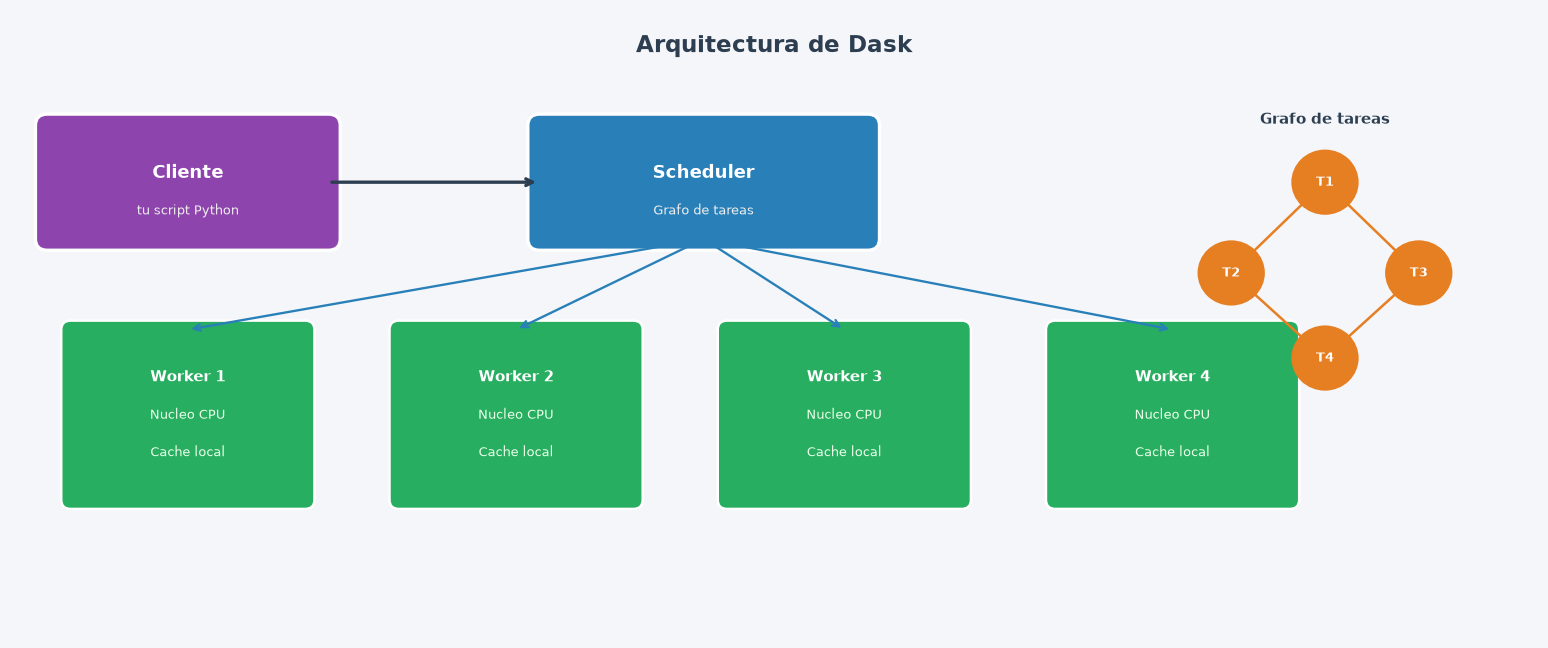

Diagrama 2: Arquitectura de Dask


In [7]:
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.set_xlim(0, 13)
ax.set_ylim(0, 5.5)
ax.set_axis_off()
ax.set_facecolor('#f5f6fa')
fig.patch.set_facecolor('#f5f6fa')

ax.text(6.5, 5.2, 'Arquitectura de Dask', ha='center', va='center',
        fontsize=14, fontweight='bold', color='#2c3e50')

# Cliente
box_cli = FancyBboxPatch((0.3, 3.5), 2.4, 1.0,
                          boxstyle="round,pad=0.1",
                          facecolor='#8e44ad', edgecolor='white', linewidth=2)
ax.add_patch(box_cli)
ax.text(1.5, 4.08, 'Cliente', ha='center', va='center',
        fontsize=11, fontweight='bold', color='white')
ax.text(1.5, 3.75, 'tu script Python', ha='center', va='center',
        fontsize=8, color='#eeeeee')

# Scheduler
box_sch = FancyBboxPatch((4.5, 3.5), 2.8, 1.0,
                          boxstyle="round,pad=0.1",
                          facecolor='#2980b9', edgecolor='white', linewidth=2)
ax.add_patch(box_sch)
ax.text(5.9, 4.08, 'Scheduler', ha='center', va='center',
        fontsize=11, fontweight='bold', color='white')
ax.text(5.9, 3.75, 'Grafo de tareas', ha='center', va='center',
        fontsize=8, color='#eeeeee')

ax.annotate('', xy=(4.5, 4.0), xytext=(2.7, 4.0),
            arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=2.0))

# Workers
xs_w = [0.5, 3.3, 6.1, 8.9]
for i, xw in enumerate(xs_w):
    box_w = FancyBboxPatch((xw, 1.2), 2.0, 1.5,
                           boxstyle="round,pad=0.08",
                           facecolor='#27ae60', edgecolor='white', linewidth=1.5)
    ax.add_patch(box_w)
    ax.text(xw + 1.0, 2.28, f'Worker {i + 1}', ha='center', va='center',
            fontsize=9, fontweight='bold', color='white')
    ax.text(xw + 1.0, 1.95, 'Nucleo CPU', ha='center', va='center',
            fontsize=7.5, color='#eaffea')
    ax.text(xw + 1.0, 1.62, 'Cache local', ha='center', va='center',
            fontsize=7.5, color='#eaffea')
    ax.annotate('', xy=(xw + 1.0, 2.7), xytext=(5.9, 3.5),
                arrowprops=dict(arrowstyle='->', color='#2980b9', lw=1.4))

# Grafo de tareas decorativo
ax.text(11.2, 4.55, 'Grafo de tareas', ha='center', va='center',
        fontsize=9, fontweight='bold', color='#2c3e50')
nodos = [(11.2, 4.0, 'T1'), (10.4, 3.2, 'T2'), (12.0, 3.2, 'T3'), (11.2, 2.45, 'T4')]
for xn, yn, tn in nodos:
    circ = plt.Circle((xn, yn), 0.28, color='#e67e22', zorder=3)
    ax.add_patch(circ)
    ax.text(xn, yn, tn, ha='center', va='center',
            fontsize=8, fontweight='bold', color='white', zorder=4)
for i1, i2 in [(0, 1), (0, 2), (1, 3), (2, 3)]:
    x1, y1 = nodos[i1][0], nodos[i1][1]
    x2, y2 = nodos[i2][0], nodos[i2][1]
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#e67e22', lw=1.5))

plt.tight_layout()
plt.savefig('diagrama_b3_dask.png', dpi=120, bbox_inches='tight')
plt.show()
print("Diagrama 2: Arquitectura de Dask")


In [8]:
r = subprocess.run(
    ['pip', 'install', 'dask', '--quiet', '--break-system-packages'],
    capture_output=True, text=True
)
print("dask instalado." if r.returncode == 0 else r.stderr[:300])

import dask
import dask.array as da
print(f"Version de Dask: {dask.__version__}")

# Arrays Dask con evaluacion diferida
x = da.random.random((10_000, 1_000), chunks=(1_000, 200))
print(f"Array Dask: shape={x.shape}  chunk=(1000, 200)")
print(f"Tipo del objeto: {type(x)}")

media_cols = x.mean(axis=0)
print(f"Primeras 5 medias de columnas: {media_cols.compute()[:5].round(4)}")
print("(.compute() ejecuto los calculos en paralelo sobre todos los chunks)")


dask instalado.
Version de Dask: 2026.7.1
Array Dask: shape=(10000, 1000)  chunk=(1000, 200)
Tipo del objeto: <class 'dask.array.core.Array'>
Primeras 5 medias de columnas: [0.4998 0.5029 0.4972 0.4978 0.4995]
(.compute() ejecuto los calculos en paralelo sobre todos los chunks)


In [9]:
import dask.dataframe as dd

t0 = time.perf_counter()
ddf = dd.read_csv(RUTA_CSV)
t_read = time.perf_counter() - t0
print(f"dd.read_csv(): {t_read:.4f} s  (lazy, no ha leido el fichero)")
print(f"Tipo:          {type(ddf)}")
print(f"Columnas:      {list(ddf.columns)}")
print(f"Particiones:   {ddf.npartitions}")

t0 = time.perf_counter()
medias_dask = ddf.groupby('sensor')['valor'].mean().compute()
t_dask = time.perf_counter() - t0
print(f"Media por sensor (Dask) en {t_dask:.3f} s")
print(medias_dask.sort_index())


dd.read_csv(): 0.0220 s  (lazy, no ha leido el fichero)
Tipo:          <class 'dask.dataframe.dask_expr._collection.DataFrame'>
Columnas:      ['id', 'sensor', 'valor', 'temperatura', 'activo']
Particiones:   1
Media por sensor (Dask) en 1.121 s
sensor
A   -0.001618
B   -0.003628
C    0.000185
D   -0.000277
Name: valor, dtype: float64


In [10]:
from dask import delayed

@delayed
def leer_fragmento(seed, n):
    np.random.seed(seed)
    return np.random.randn(n)

@delayed
def calcular_media(arr):
    return float(np.mean(arr))

@delayed
def combinar(lista_medias):
    return float(np.mean(lista_medias))

# Construir el grafo (no ejecuta nada todavia)
fragmentos   = [leer_fragmento(i, 10_000) for i in range(8)]
medias_frag  = [calcular_media(f) for f in fragmentos]
media_global = combinar(medias_frag)

print(f"Tipo de media_global: {type(media_global)}  (no calculado todavia)")

t0 = time.perf_counter()
resultado = media_global.compute()
t_delay = time.perf_counter() - t0
print(f"Media calculada: {resultado:.6f}  (en {t_delay:.3f} s, paralelo)")


Tipo de media_global: <class 'dask.delayed.Delayed'>  (no calculado todavia)
Media calculada: -0.002252  (en 0.016 s, paralelo)


---
## 3.4 Apache Spark: arquitectura y modelo MapReduce

**Apache Spark** es el motor de procesamiento distribuido más usado en proyectos de ML
a gran escala. A diferencia de Dask (un nodo o clúster Python), Spark está diseñado para
clústeres de miles de nodos y petabytes de datos.

### Arquitectura

```
Driver Program (SparkContext / SparkSession)
    |
    +-- Cluster Manager (YARN / Kubernetes / Standalone)
            |
            +-- Worker 1:  Executor  [Task][Task][Cache]
            +-- Worker 2:  Executor  [Task][Task][Cache]
            +-- Worker N:  Executor  [Task][Task][Cache]
```

### Abstracciones principales

| Abstracción | Descripción | Evaluación |
|-------------|-------------|-----------|
| **RDD** (Resilient Distributed Dataset) | Colección distribuida, tolerante a fallos | Lazy |
| **DataFrame** | RDD con esquema tipado, optimizable con Catalyst | Lazy |
| **Dataset** | DataFrame tipado en compilación (Scala/Java) | Lazy |

### Transformaciones vs Acciones

- **Transformaciones** (lazy): `map`, `filter`, `groupBy`, `join` → definen el grafo DAG
- **Acciones** (disparan la ejecución): `count`, `collect`, `show`, `write` → ejecutan el grafo

> **Instalación:** PySpark requiere Java 8/11 y el paquete `pip install pyspark`.
> En desarrollo local se usa el modo `local[*]` (todos los núcleos de la máquina).

El diagrama siguiente muestra la arquitectura completa de un clúster Spark.


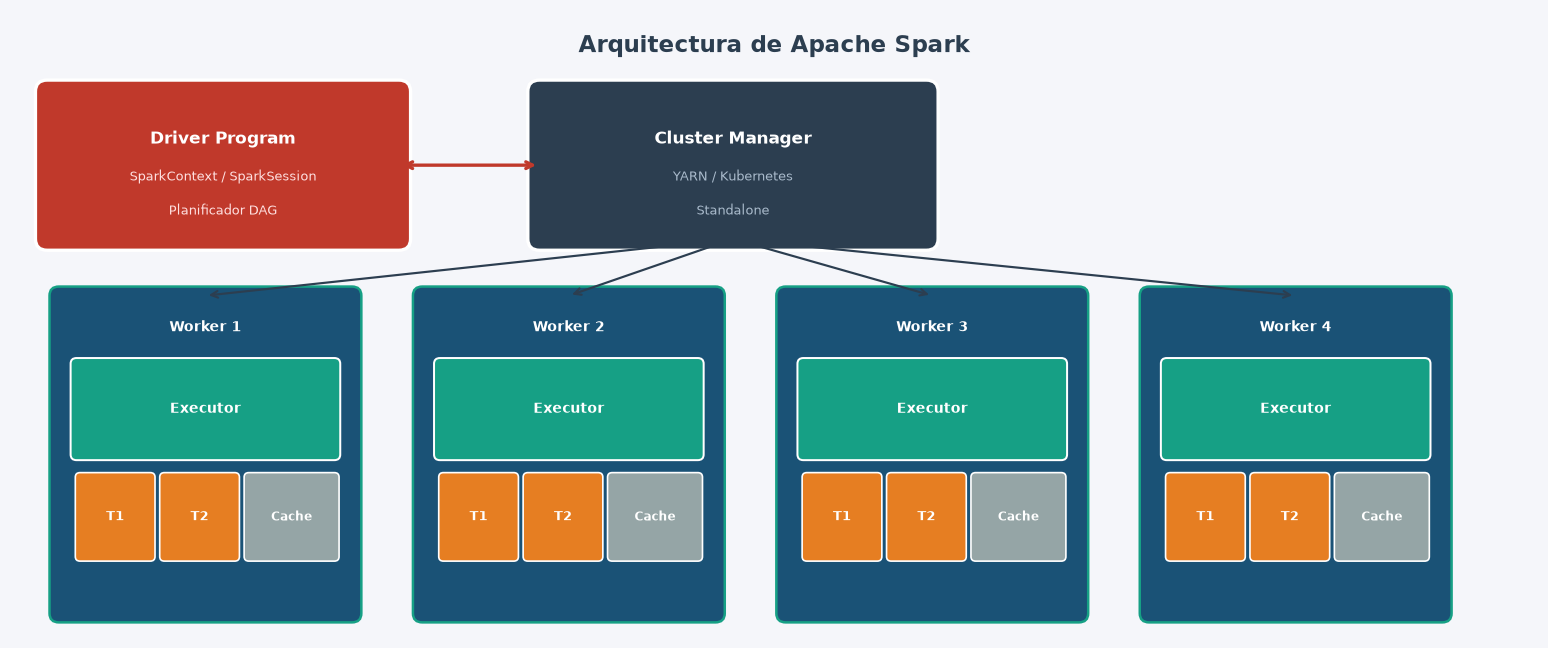

Diagrama 3: Arquitectura de Apache Spark


In [11]:
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.set_xlim(0, 13)
ax.set_ylim(0, 5.5)
ax.set_axis_off()
ax.set_facecolor('#f5f6fa')
fig.patch.set_facecolor('#f5f6fa')

ax.text(6.5, 5.2, 'Arquitectura de Apache Spark', ha='center', va='center',
        fontsize=14, fontweight='bold', color='#2c3e50')

# Driver Program
drv = FancyBboxPatch((0.3, 3.5), 3.0, 1.3,
                     boxstyle="round,pad=0.1",
                     facecolor='#c0392b', edgecolor='white', linewidth=2)
ax.add_patch(drv)
ax.text(1.8, 4.38, 'Driver Program', ha='center', va='center',
        fontsize=10, fontweight='bold', color='white')
ax.text(1.8, 4.05, 'SparkContext / SparkSession', ha='center', va='center',
        fontsize=7.5, color='#ffe0e0')
ax.text(1.8, 3.75, 'Planificador DAG', ha='center', va='center',
        fontsize=7.5, color='#ffe0e0')

# Cluster Manager
mgr = FancyBboxPatch((4.5, 3.5), 3.3, 1.3,
                     boxstyle="round,pad=0.1",
                     facecolor='#2c3e50', edgecolor='white', linewidth=2)
ax.add_patch(mgr)
ax.text(6.15, 4.38, 'Cluster Manager', ha='center', va='center',
        fontsize=10, fontweight='bold', color='white')
ax.text(6.15, 4.05, 'YARN / Kubernetes', ha='center', va='center',
        fontsize=7.5, color='#aabbcc')
ax.text(6.15, 3.75, 'Standalone', ha='center', va='center',
        fontsize=7.5, color='#aabbcc')

ax.annotate('', xy=(4.5, 4.15), xytext=(3.3, 4.15),
            arrowprops=dict(arrowstyle='<->', color='#c0392b', lw=2.0))

# Workers
xs_w = [0.4, 3.5, 6.6, 9.7]
for i, xw in enumerate(xs_w):
    wbox = FancyBboxPatch((xw, 0.2), 2.5, 2.8,
                          boxstyle="round,pad=0.08",
                          facecolor='#1a5276', edgecolor='#16a085', linewidth=1.5)
    ax.add_patch(wbox)
    ax.text(xw + 1.25, 2.72, f'Worker {i + 1}', ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white')
    ebox = FancyBboxPatch((xw + 0.15, 1.6), 2.2, 0.8,
                          boxstyle="round,pad=0.05",
                          facecolor='#16a085', edgecolor='white', linewidth=1.2)
    ax.add_patch(ebox)
    ax.text(xw + 1.25, 2.0, 'Executor', ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white')
    for ti, tx in enumerate([xw + 0.18, xw + 0.9]):
        tbox = FancyBboxPatch((tx, 0.7), 0.6, 0.7,
                              boxstyle="round,pad=0.04",
                              facecolor='#e67e22', edgecolor='white', linewidth=1)
        ax.add_patch(tbox)
        ax.text(tx + 0.3, 1.05, f'T{ti + 1}', ha='center', va='center',
                fontsize=7.5, fontweight='bold', color='white')
    cbox = FancyBboxPatch((xw + 1.62, 0.7), 0.73, 0.7,
                          boxstyle="round,pad=0.04",
                          facecolor='#95a5a6', edgecolor='white', linewidth=1)
    ax.add_patch(cbox)
    ax.text(xw + 1.985, 1.05, 'Cache', ha='center', va='center',
            fontsize=7, fontweight='bold', color='white')
    ax.annotate('', xy=(xw + 1.25, 3.0), xytext=(6.15, 3.5),
                arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=1.3))

plt.tight_layout()
plt.savefig('diagrama_b3_spark.png', dpi=120, bbox_inches='tight')
plt.show()
print("Diagrama 3: Arquitectura de Apache Spark")


In [12]:
# Simulacion del modelo MapReduce con Python puro
# (Spark hace exactamente esto, distribuido entre maquinas)
from functools import reduce as f_reduce
from collections import defaultdict

ventas = [
    ('Madrid',    1200), ('Barcelona', 850), ('Madrid',    950),
    ('Sevilla',   430),  ('Barcelona', 760), ('Sevilla',   520),
    ('Madrid',    1100), ('Valencia',  670), ('Valencia',  390),
    ('Barcelona', 910),  ('Madrid',    780), ('Valencia',  540),
]

print("=== Paso 1: MAP ===")
mapeado = list(map(lambda v: (v[0], v[1]), ventas))
print(f"  {mapeado[:4]} ...")

print()
print("=== Paso 2: SHUFFLE / GROUP BY ===")
agrupado = defaultdict(list)
for ciudad, importe in mapeado:
    agrupado[ciudad].append(importe)
for ciudad, importes in sorted(agrupado.items()):
    print(f"  {ciudad}: {importes}")

print()
print("=== Paso 3: REDUCE ===")
reducido = {ciudad: f_reduce(lambda a, b: a + b, importes)
            for ciudad, importes in agrupado.items()}
for ciudad, total in sorted(reducido.items()):
    print(f"  {ciudad:12s}: {total:,} euros")

print()
print("--- En PySpark seria: ---")
print("  sc = SparkContext()")
print("  rdd = sc.parallelize(ventas)")
print("  resultado = rdd.reduceByKey(lambda a, b: a + b).collect()")


=== Paso 1: MAP ===
  [('Madrid', 1200), ('Barcelona', 850), ('Madrid', 950), ('Sevilla', 430)] ...

=== Paso 2: SHUFFLE / GROUP BY ===
  Barcelona: [850, 760, 910]
  Madrid: [1200, 950, 1100, 780]
  Sevilla: [430, 520]
  Valencia: [670, 390, 540]

=== Paso 3: REDUCE ===
  Barcelona   : 2,520 euros
  Madrid      : 4,030 euros
  Sevilla     : 950 euros
  Valencia    : 1,600 euros

--- En PySpark seria: ---
  sc = SparkContext()
  rdd = sc.parallelize(ventas)
  resultado = rdd.reduceByKey(lambda a, b: a + b).collect()


---
## 3.5 Particionado, shuffling y optimización

El **particionado** determina cómo se distribuyen los datos entre los nodos del clúster.
Una mala estrategia de particionado es la causa más frecuente de rendimiento pobre.

### Estrategias de particionado

| Estrategia | Cómo asigna datos | Cuándo usarla |
|------------|-------------------|---------------|
| **Hash** | `hash(clave) % N_particiones` | Joins y groupBy sobre clave de alta cardinalidad |
| **Rango** | Ordena y divide en intervalos iguales | OrderBy, ventanas temporales |
| **Round-robin** | Distribución circular aleatoria | Cargas iniciales, sin clave de join |
| **Custom** | Función definida por el usuario | Por fecha, región geográfica, etc. |

### El shuffle: el cuello de botella

El **shuffle** ocurre cuando Spark redistribuye datos entre particiones (en un `groupBy` o `join`).
Es costoso porque requiere serializar, transferir por red y ordenar en destino.

**Truco práctico:** en un join repetido, usa `broadcast join` para la tabla pequeña y evita
el shuffle de la tabla grande.

El diagrama muestra cómo tres estrategias asignan los mismos datos a las particiones.


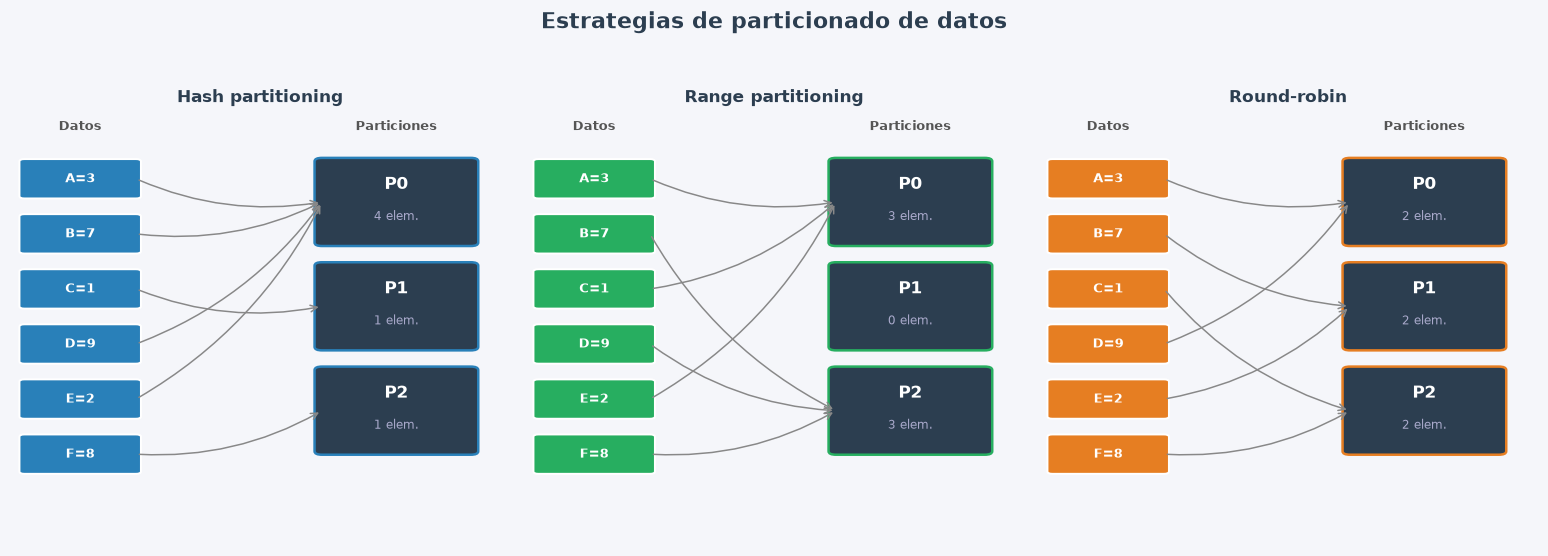

Diagrama 4: Estrategias de particionado


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
fig.patch.set_facecolor('#f5f6fa')

titulos = ['Hash partitioning', 'Range partitioning', 'Round-robin']
colores = ['#2980b9', '#27ae60', '#e67e22']
datos_kv = [('A', 3), ('B', 7), ('C', 1), ('D', 9), ('E', 2), ('F', 8)]
N_PART = 3

def hash_asign(k):   return hash(k) % N_PART
def range_asign(v):  return 0 if v <= 3 else (1 if v <= 6 else 2)
def robin_asign(i):  return i % N_PART

asignaciones = [
    [hash_asign(k) for k, v in datos_kv],
    [range_asign(v) for k, v in datos_kv],
    [robin_asign(i) for i, _ in enumerate(datos_kv)],
]

for ax, titulo, color, asign in zip(axes, titulos, colores, asignaciones):
    ax.set_xlim(0, 4)
    ax.set_ylim(-0.5, 7.5)
    ax.set_axis_off()
    ax.set_facecolor('#f5f6fa')
    ax.text(2.0, 7.2, titulo, ha='center', va='center',
            fontsize=10, fontweight='bold', color='#2c3e50')
    ax.text(0.55, 6.7, 'Datos', ha='center', va='center',
            fontsize=8, fontweight='bold', color='#555555')
    for j, (k, v) in enumerate(datos_kv):
        yj = 5.8 - j * 0.95
        box = FancyBboxPatch((0.1, yj - 0.3), 0.9, 0.6,
                             boxstyle="round,pad=0.04",
                             facecolor=color, edgecolor='white', linewidth=1.2)
        ax.add_patch(box)
        ax.text(0.55, yj, f'{k}={v}', ha='center', va='center',
                fontsize=8, fontweight='bold', color='white')
    ax.text(3.1, 6.7, 'Particiones', ha='center', va='center',
            fontsize=8, fontweight='bold', color='#555555')
    y_parts = [5.4, 3.6, 1.8]
    for p, yp in enumerate(y_parts):
        pbox = FancyBboxPatch((2.5, yp - 0.7), 1.2, 1.4,
                              boxstyle="round,pad=0.06",
                              facecolor='#2c3e50', edgecolor=color, linewidth=1.5)
        ax.add_patch(pbox)
        ax.text(3.1, yp + 0.3, f'P{p}', ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')
        n_elem = asign.count(p)
        ax.text(3.1, yp - 0.25, f'{n_elem} elem.', ha='center', va='center',
                fontsize=7, color='#aaaacc')
    for j, p in enumerate(asign):
        y_src = 5.8 - j * 0.95
        y_dst = y_parts[p]
        ax.annotate('', xy=(2.5, y_dst), xytext=(1.0, y_src),
                    arrowprops=dict(arrowstyle='->', color='#888888', lw=0.9,
                                   connectionstyle='arc3,rad=0.15'))

plt.suptitle('Estrategias de particionado de datos', fontsize=13,
             fontweight='bold', color='#2c3e50', y=1.02)
plt.tight_layout()
plt.savefig('diagrama_b3_particionado.png', dpi=120, bbox_inches='tight')
plt.show()
print("Diagrama 4: Estrategias de particionado")


In [14]:
# Benchmark: pandas chunks vs Dask
import warnings
warnings.filterwarnings('ignore')

print("Benchmark: pandas-chunks vs Dask")
print(f"Dataset: {RUTA_CSV.name}  ({RUTA_CSV.stat().st_size / 1e6:.1f} MB)")
print("-" * 52)

# --- pandas por chunks ---
t0 = time.perf_counter()
acc = {}
for chunk in pd.read_csv(RUTA_CSV, chunksize=50_000):
    sub = chunk[chunk['activo'] == True]
    for s, g in sub.groupby('sensor'):
        if s not in acc:
            acc[s] = 0.0
        acc[s] += g['valor'].sum()
t_pd = time.perf_counter() - t0
print(f"pandas chunks:  {t_pd:.3f} s")
for s in sorted(acc):
    print(f"  Sensor {s}: {acc[s]:+.2f}")

print()

# --- Dask ---
import dask.dataframe as dd
t0 = time.perf_counter()
ddf2 = dd.read_csv(RUTA_CSV)
res_dask = (ddf2[ddf2['activo'] == True]
              .groupby('sensor')['valor']
              .sum()
              .compute())
t_dask = time.perf_counter() - t0
print(f"Dask:           {t_dask:.3f} s")
print(res_dask.sort_index())
print()
print(f"Factor Dask vs pandas-chunks: {t_pd / t_dask:.2f}x")
print("(Dask usa multiples nucleos; pandas-chunks usa uno solo)")


Benchmark: pandas-chunks vs Dask
Dataset: datos_grandes.csv  (31.9 MB)
----------------------------------------------------
pandas chunks:  0.739 s
  Sensor A: -206.72
  Sensor B: -293.21
  Sensor C: +233.74
  Sensor D: +72.51

Dask:           0.665 s
sensor
A   -206.715773
B   -293.212060
C    233.739464
D     72.505630
Name: valor, dtype: float64

Factor Dask vs pandas-chunks: 1.11x
(Dask usa multiples nucleos; pandas-chunks usa uno solo)


---
## 3.6 Aprendizaje online y streaming con scikit-learn

El **aprendizaje online** permite actualizar el modelo **incrementalmente** con cada mini-lote
de datos, sin necesidad de acceder a todo el dataset de una vez.

### ¿Cuándo usar aprendizaje online?

- Los datos llegan en tiempo real (logs, sensores IoT, transacciones)
- El dataset es demasiado grande para caber en RAM
- El patrón en los datos puede cambiar con el tiempo (**concept drift**)

### API `partial_fit` en scikit-learn

| Estimador | Tipo |
|-----------|------|
| `SGDClassifier` | Clasificación (SVM lineal, Regresión Logística) |
| `SGDRegressor` | Regresión lineal |
| `MiniBatchKMeans` | Clustering incremental |
| `IncrementalPCA` | Reducción de dimensionalidad |
| `StandardScaler` | Normalización incremental |

El diagrama siguiente muestra el pipeline completo de streaming con aprendizaje online.


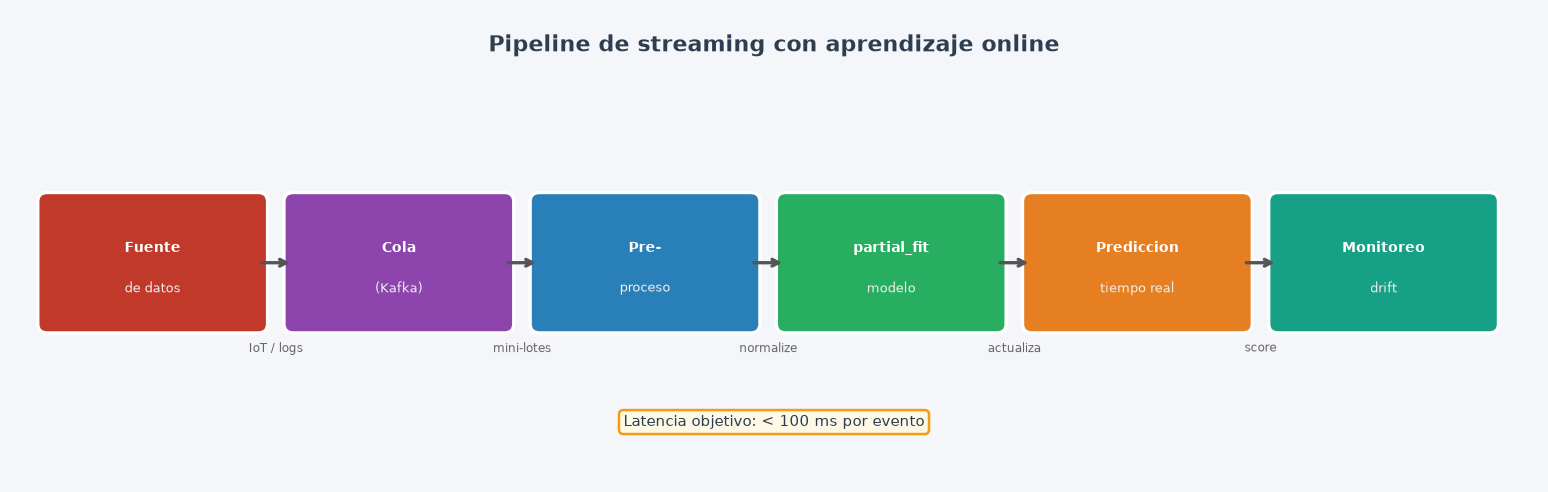

Diagrama 5: Pipeline de streaming con aprendizaje online


In [15]:
fig, ax = plt.subplots(figsize=(13, 4.2))
ax.set_xlim(0, 13)
ax.set_ylim(0, 4.2)
ax.set_axis_off()
ax.set_facecolor('#f5f6fa')
fig.patch.set_facecolor('#f5f6fa')

ax.text(6.5, 3.9, 'Pipeline de streaming con aprendizaje online', ha='center', va='center',
        fontsize=13, fontweight='bold', color='#2c3e50')

# Componentes: (x0, linea1, linea2, color)
componentes = [
    (0.3,  'Fuente',       'de datos',   '#c0392b'),
    (2.4,  'Cola',         '(Kafka)',     '#8e44ad'),
    (4.5,  'Pre-',         'proceso',    '#2980b9'),
    (6.6,  'partial_fit',  'modelo',     '#27ae60'),
    (8.7,  'Prediccion',   'tiempo real','#e67e22'),
    (10.8, 'Monitoreo',    'drift',      '#16a085'),
]
w = 1.8
h = 1.1

for x0, l1, l2, color in componentes:
    box = FancyBboxPatch((x0, 1.4), w, h,
                         boxstyle="round,pad=0.08",
                         facecolor=color, edgecolor='white', linewidth=2)
    ax.add_patch(box)
    ax.text(x0 + w / 2, 2.08, l1, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white')
    ax.text(x0 + w / 2, 1.72, l2, ha='center', va='center',
            fontsize=7.5, color='#eeeeee')

flujos = ['IoT / logs', 'mini-lotes', 'normalize', 'actualiza', 'score', 'alerta']
xs_comp = [c[0] for c in componentes]
for i in range(len(xs_comp) - 1):
    x_src = xs_comp[i] + w
    x_dst = xs_comp[i + 1]
    ymid  = 1.95
    ax.annotate('', xy=(x_dst, ymid), xytext=(x_src, ymid),
                arrowprops=dict(arrowstyle='->', color='#555555', lw=2.0))
    xmid = (x_src + x_dst) / 2
    ax.text(xmid, 1.18, flujos[i], ha='center', va='center',
            fontsize=7, color='#666666')

ax.text(6.5, 0.52, 'Latencia objetivo: < 100 ms por evento', ha='center', va='center',
        fontsize=9, color='#2c3e50',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#fef9e7',
                  edgecolor='#f39c12', linewidth=1.5))

plt.tight_layout()
plt.savefig('diagrama_b3_streaming.png', dpi=120, bbox_inches='tight')
plt.show()
print("Diagrama 5: Pipeline de streaming con aprendizaje online")


In [16]:
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

np.random.seed(42)

N_EVENTOS  = 20_000
LOTE       = 500
N_FEATURES = 6

clf    = SGDClassifier(loss='log_loss', max_iter=1, tol=None, random_state=42)
scaler = StandardScaler()

acuracidades = []
tiempos_lote = []

print("Simulacion de streaming con aprendizaje online")
print(f"Total eventos: {N_EVENTOS:,}  |  Tamano de lote: {LOTE}")
print("-" * 56)

for i, inicio in enumerate(range(0, N_EVENTOS, LOTE)):
    t_lote = time.perf_counter()

    X_lote = np.random.randn(LOTE, N_FEATURES)
    y_lote = (X_lote[:, 0] + X_lote[:, 1] + X_lote[:, 2] > 0).astype(int)

    scaler.partial_fit(X_lote)
    X_sc = scaler.transform(X_lote)

    clf.partial_fit(X_sc, y_lote, classes=[0, 1])

    acc = accuracy_score(y_lote, clf.predict(X_sc))
    acuracidades.append(acc)
    tiempos_lote.append(time.perf_counter() - t_lote)

    if i % 8 == 0:
        print(f"  Lote {i + 1:3d}  |  Eventos: {inicio + LOTE:6,}  |  acc = {acc:.3f}")

print("-" * 56)
print(f"Accuracy media:    {np.mean(acuracidades):.4f}")
print(f"Accuracy final:    {acuracidades[-1]:.4f}")
print(f"Tiempo medio/lote: {np.mean(tiempos_lote) * 1000:.2f} ms")
print(f"Throughput:        {LOTE / np.mean(tiempos_lote):,.0f} eventos/segundo")


Simulacion de streaming con aprendizaje online
Total eventos: 20,000  |  Tamano de lote: 500
--------------------------------------------------------
  Lote   1  |  Eventos:    500  |  acc = 0.930
  Lote   9  |  Eventos:  4,500  |  acc = 0.992
  Lote  17  |  Eventos:  8,500  |  acc = 0.984
  Lote  25  |  Eventos: 12,500  |  acc = 0.994
  Lote  33  |  Eventos: 16,500  |  acc = 0.984
--------------------------------------------------------
Accuracy media:    0.9806
Accuracy final:    0.9960
Tiempo medio/lote: 3.30 ms
Throughput:        151,493 eventos/segundo


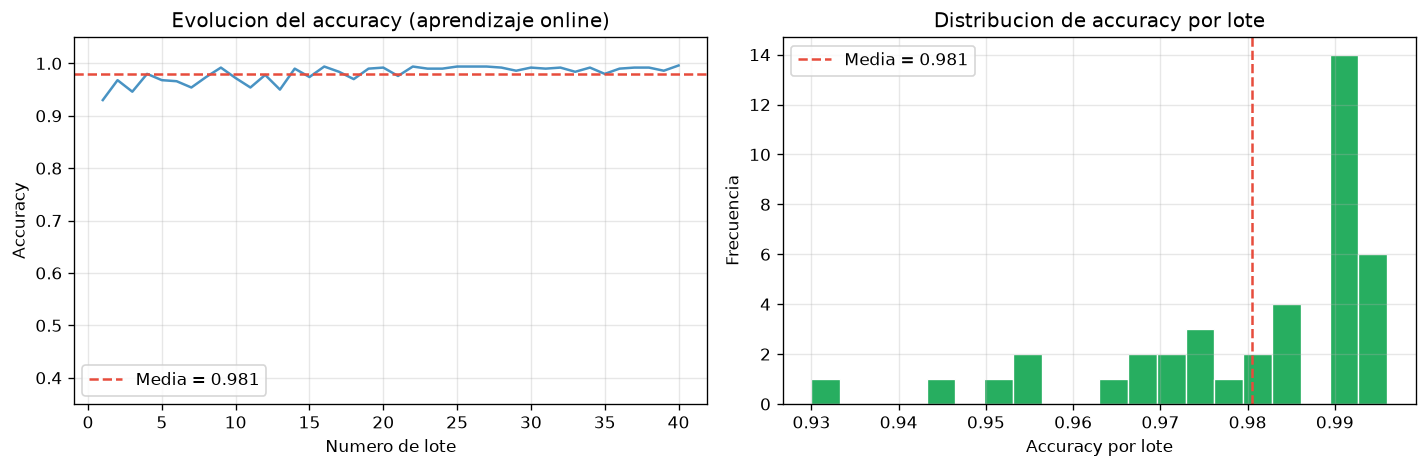

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
lotes = list(range(1, len(acuracidades) + 1))

ax1.plot(lotes, acuracidades, color='#2980b9', linewidth=1.5, alpha=0.85)
ax1.axhline(np.mean(acuracidades), color='#e74c3c', linestyle='--', linewidth=1.5,
            label=f'Media = {np.mean(acuracidades):.3f}')
ax1.set_xlabel('Numero de lote')
ax1.set_ylabel('Accuracy')
ax1.set_title('Evolucion del accuracy (aprendizaje online)')
ax1.legend()
ax1.set_ylim(0.35, 1.05)
ax1.grid(True, alpha=0.3)

ax2.hist(acuracidades, bins=20, color='#27ae60', edgecolor='white', linewidth=0.8)
ax2.axvline(np.mean(acuracidades), color='#e74c3c', linestyle='--', linewidth=1.5,
            label=f'Media = {np.mean(acuracidades):.3f}')
ax2.set_xlabel('Accuracy por lote')
ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribucion de accuracy por lote')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## Resumen del bloque

| Técnica | Herramienta | Escala | Latencia | Requiere |
|---------|------------|--------|----------|---------|
| Chunks pandas | `pd.read_csv(chunksize=N)` | GB | Batch | Solo pandas |
| Paralelismo local | Dask | GB – TB | Batch / micro | `pip install dask` |
| Clúster distribuido | Apache Spark | TB – PB | Batch / stream | Java + clúster |
| Aprendizaje online | `partial_fit` (sklearn) | Ilimitado | Streaming | Solo sklearn |

---

### Ejercicios propuestos

1. **Chunks con varianza:** Modifica la celda de procesamiento por chunks para calcular también
   la **desviación típica** de `temperatura` por sensor usando las fórmulas de varianza acumulada
   (sin cargar todo en RAM). _Pista: acumula suma de cuadrados y suma._

2. **Dask delayed personalizado:** Crea una función `procesar_fichero(ruta)` decorada con
   `@delayed` que lea un CSV, filtre filas con `activo == True` y devuelva la media de `valor`.
   Ejecuta 4 ficheros en paralelo con `dask.compute()`.

3. **Word count MapReduce:** Implementa en Python puro el conteo de palabras de un texto largo
   usando `map`, `defaultdict` y `sorted`. Compara con `collections.Counter`.

4. **Concept drift:** Modifica la simulación de streaming para que en el lote 25 el patrón cambie
   (invierte la regla de clasificación). Observa cómo cae la accuracy y cuántos lotes tarda el
   modelo en recuperarse.

5. **Dask vs pandas big:** Aumenta `N_FILAS` a `2_000_000` y repite el benchmark.
   ¿A partir de qué tamaño Dask es claramente más rápido? ¿Por qué puede ser más lento
   con ficheros pequeños?

---
_Fin del Bloque 3.
El Bloque 4 cubre el diseño y construcción de pipelines ETL/ELT completos._
